# Osu benchmark

Osu microbenchmark Alltoallv from 1024 up to 67108864.

Native vs Container

In [25]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [26]:
df_native = pd.read_csv(
    "../parallel/results/osu_native.txt",
    sep=r"\s+"
)
df_native["version"] = "Native"

df_native.head()

,Size,Avg_Latency(us),version
0,1024,25.39,Native
1,2048,33.24,Native
2,4096,54.26,Native
3,8192,79.10,Native
4,16384,75.55,Native


In [ ]:
df_container = pd.read_csv(
    "../parallel/results/osu_container.txt",
    sep=r"\s+"
)
df_container["version"] = "Container"

df_container.head()

,Size,Avg_Latency(us),version
0,1024,25.39,Container
1,2048,33.24,Container
2,4096,54.26,Container
3,8192,79.10,Container
4,16384,75.55,Container


In [28]:
results = pd.merge(df_native, df_container, "outer")
results.head(30)

,Size,Avg_Latency(us),version
0,1024,18.45,NaN
1,1024,25.39,Container
2,2048,30.30,NaN
3,2048,33.24,Container
4,4096,54.26,Container
5,4096,96.59,NaN
6,8192,79.10,Container
7,8192,111.56,NaN
8,16384,75.55,Container
9,16384,191.74,NaN


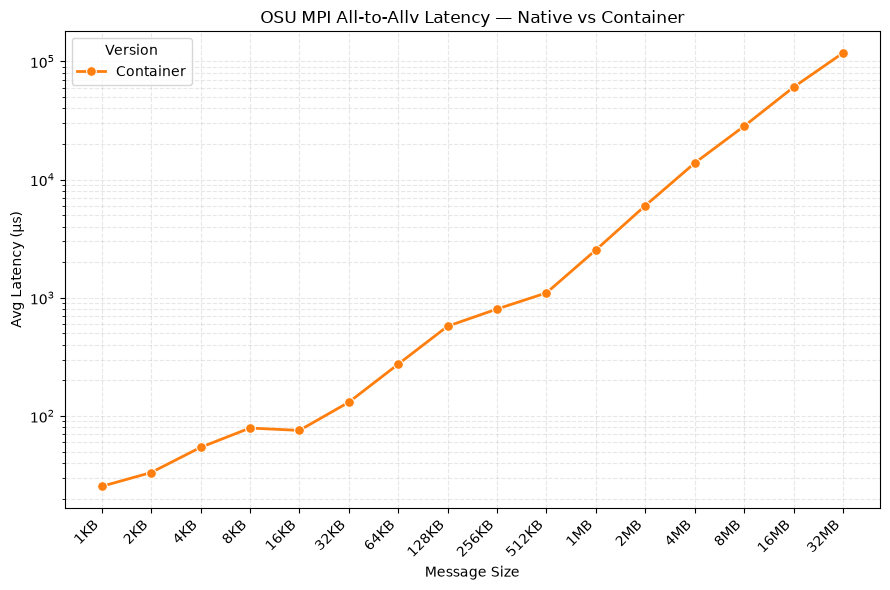

In [29]:
custom_palette = {
    "Native": "#1f77b4",
    "Container": "#ff7f0e"
}

plt.figure(figsize=(9, 6))

sns.lineplot(
    data=results,
    x="Size",
    y="Avg_Latency(us)",
    hue="version",
    style="version",
    markers=True,
    dashes=False,
    palette=custom_palette,
    linewidth=2,
    markersize=7,
)

# Set logarithmic scale for both axes
plt.xscale("log", base=2)
plt.yscale("log", base=10)

unique_sizes = sorted(results["Size"].unique())

def format_bytes(size):
    if size >= 1024 * 1024:
        return f"{int(size / (1024 * 1024))}MB"
    elif size >= 1024:
        return f"{int(size / 1024)}KB"
    return f"{size}B"

plt.xticks(
    unique_sizes,
    [format_bytes(s) for s in unique_sizes],
    rotation=45,
    ha="right",
)

plt.xlabel("Message Size")
plt.ylabel("Avg Latency (μs)")
plt.title("OSU MPI All-to-Allv Latency — Native vs Container")
plt.grid(True, which="both", linestyle="--", alpha=0.3)
plt.legend(title="Version")
plt.tight_layout()

plt.show()